##  **Détection DDoS : Un Système de Détection Multiclasse et Multidimensionnel avec Divers Modèles de Machine Learning**

---

###  **Aperçu du Projet**

Ce projet vise à construire un système capable de **détecter et classifier** les attaques **DDoS (Déni de Service Distribué)** en utilisant le jeu de données **CICDDoS2019**. L'objectif est de développer un modèle de **classification multiclasse** capable d'identifier différents types d'attaques DDoS à partir du trafic réseau normal. Le jeu de données comprend plusieurs types d'attaques ayant des caractéristiques de trafic réseau différentes, ce qui en fait un problème complexe pour la détection DDoS.

---

###  **Description du Jeu de Données**

Le jeu de données **CICDDoS2019**, fourni par l'Institut Canadien pour la Cybersécurité (CIC), contient des données de trafic réseau représentant plusieurs types d'attaques DDoS ainsi que du trafic bénin (non-attaque). Le jeu de données comporte plusieurs attributs comme la taille des paquets, les adresses IP source/destination et les types de protocoles. La variable cible est composée de différentes étiquettes d'attaques :

| Étiquette | Description |
|-----------|-------------|
| **Syn** | Attaque par inondation SYN |
| **Benign** | Trafic normal (non-attaque) |
| **UDP** | Attaque par inondation UDP générique |
| **MSSQL** | Attaque DDoS spécifique à MSSQL |
| **NetBIOS** | Attaque DDoS liée à NetBIOS |
| **LDAP** | Attaque basée sur le protocole LDAP |

---

###  **Aperçu du Processus**

####  **Collecte et Prétraitement des Données**

1. **Collecte des Chemins des Données** :
   - Les chemins des ensembles d'entraînement et de test sont collectés en parcourant les dossiers.
   - On s'assure que seuls les ensembles de données avec des noms correspondants sont utilisés pour l'entraînement et le test.

2. **Traitement des Données** :
   - **Mappage des Colonnes** : On mappe les noms de colonnes entre les ensembles d'entraînement et de test pour garantir leur cohérence. Les noms de colonnes dans l'ensemble de test sont renommés pour correspondre à ceux de l'ensemble d'entraînement.
   - **Gestion des Valeurs Nulles et Doublons** : On vérifie les valeurs nulles ou les doublons. Aucune valeur nulle n'est trouvée et les doublons sont supprimés.
   - **Suppression des Colonnes à Valeur Unique** : Les colonnes avec une seule valeur unique sont supprimées car elles n'apportent pas d'information utile.
   - **Suppression des Colonnes Fortement Corrélées** : Les colonnes avec un coefficient de corrélation ≥ 0,8 sont supprimées pour réduire la multicolinéarité et améliorer les performances du modèle.

---

###  **Analyse Exploratoire des Données (EDA)**

Plusieurs visualisations clés ont été réalisées pour comprendre le jeu de données :


- **Distribution de la Durée des Flux** :
   - Analyse de la durée des flux pour le trafic DDoS et normal.
- **Longueur Moyenne des Paquets par Protocole et par Attaque** :
   - Exploration de la longueur moyenne des paquets par type de protocole et par type d'attaque.
- **Distribution des Flags par Type d'Attaque** :
   - Distribution des différents types de flags par type d'attaque.
- **Distribution des Demandes par Protocole** :
   - Nombre de requêtes provenant de différents protocoles.
- **Matrice de Corrélation** :
   - Heatmap pour visualiser la matrice de corrélation et identifier les relations entre les caractéristiques.

---

###  **Prétraitement des Données et Ingénierie des Caractéristiques**

- **Division Entraînement/Test** :
   - Le jeu de données est divisé en ensembles d'entraînement, de validation et de test pour assurer une évaluation correcte du modèle.
- **Encodage des Caractéristiques** :
   - La colonne cible est encodée à l'aide de **LabelEncoder** pour convertir les étiquettes catégorielles en valeurs numériques.
- **Mise à l'Échelle des Caractéristiques** :
   - On applique la **Normalisation Min-Max** pour mettre les caractéristiques à l'échelle, améliorant ainsi les performances des algorithmes basés sur la distance.

---

###  **Entraînement et Évaluation du Modèle**

- **Sélection du Modèle** :
   - Plusieurs modèles sont entraînés et évalués pour la classification multiclasse, notamment :
     - **Forêt Aléatoire (Random Forest)**
     - **Extra Trees Classifier**
     - **XGBoost**

- **Évaluation du Modèle** :
   - On évalue les modèles à l'aide de diverses métriques comme la **précision (accuracy)**, la **précision (precision)**, le **rappel (recall)**, le **score F1** et l'**AUC ROC**.
   - Les courbes ROC sont tracées pour comparer les performances de chaque modèle à travers les différentes classes.
   - Un tableau des scores des modèles est créé et affiché pour faciliter la comparaison.

---

###  **Visualisation des Résultats**

- **Comparaison des Modèles** :
   - On trace le **score de précision (accuracy)** pour chaque modèle afin de comparer visuellement leurs performances.
   - Les courbes ROC pour tous les modèles sont tracées pour analyser leur capacité de classification, en particulier pour les tâches de classification multiclasse.

---



## 📚 Importation des Bibliothèques

In [ ]:
import os
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.figure as fig
import matplotlib.cm as cm
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, roc_curve


from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

import pickle
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier

from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

# Métriques
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, classification_report)
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')
import warnings
warnings.filterwarnings('ignore')
import os, gc, warnings
import pandas as pd
import numpy as np
warnings.filterwarnings('ignore')

In [1]:
import os, kagglehub, pandas as pd, numpy as np, gc, warnings
warnings.filterwarnings('ignore')

N_PAR_CLASSE, COLS_SUPPR = 100000, ["Flow ID","Fwd Header Length.1","Source IP","Source Port","Destination IP","Timestamp","Unnamed:0","SimillarHTTP","Inbound"]
CLASSES_EXCLURE, LABEL_MAPPING = ['WebDDoS'], {'DrDoS_UDP':'UDP','DrDoS_MSSQL':'MSSQL','DrDoS_LDAP':'LDAP','DrDoS_NetBIOS':'NetBIOS','DrDoS_NTP':'NTP','DrDoS_SSDP':'SSDP','DrDoS_SNMP':'SNMP','DrDoS_DNS':'DNS','UDP-lag':'UDPLag',
                                               'TFTP':'TFTP','Syn':'Syn','Portmap':'Portmap','BENIGN':'BENIGN','Benign':'BENIGN'}

path = kagglehub.dataset_download("rodrigorosasilva/cic-ddos2019-30gb-full-dataset-csv-files")
csv_files = [(os.path.join(r,f), f) for r,_,fs in os.walk(path) for f in fs if f.endswith('.csv')]

def charger(chemin):
    reservoir, compteurs = {}, {}
    for chunk in pd.read_csv(chemin, chunksize=50000, low_memory=True, on_bad_lines='skip'):
        chunk.columns = chunk.columns.str.strip()
        if 'Label' not in chunk.columns: continue
        chunk = chunk.drop(columns=[c for c in COLS_SUPPR if c in chunk.columns], errors='ignore')
        chunk['Label'] = chunk['Label'].replace(LABEL_MAPPING)
        chunk = chunk[~chunk['Label'].isin(CLASSES_EXCLURE)]
        chunk = chunk.replace([np.inf, -np.inf], np.nan).dropna().drop_duplicates()
        for cls in chunk['Label'].unique():
            if compteurs.get(cls, 0) >= N_PAR_CLASSE: continue
            n = min(N_PAR_CLASSE - compteurs.get(cls, 0), len(chunk[chunk['Label'] == cls]))
            if n > 0:
                reservoir.setdefault(cls, []).append(chunk[chunk['Label'] == cls].sample(n=n, random_state=42))
                compteurs[cls] = compteurs.get(cls, 0) + n
        if all(compteurs.get(c, 0) >= N_PAR_CLASSE for c in reservoir): break
        del chunk; gc.collect()
    if not reservoir: return None
    df = pd.concat([pd.concat(v, ignore_index=True).drop_duplicates() for v in reservoir.values()], ignore_index=True)
    return df.sample(frac=1, random_state=42).reset_index(drop=True)

all_datasets = {f.replace('.csv','').replace('-','_').lower(): charger(p) for p, f in csv_files}
all_datasets = {k:v for k,v in all_datasets.items() if v is not None}
print(f" {len(all_datasets)} fichiers, {sum(len(v) for v in all_datasets.values()):,} lignes")

100%|██████████| 3.10G/3.10G [00:38<00:00, 86.0MB/s]

Extracting files...


 16 fichiers, 1,939,625 lignes


In [2]:
def clean_column_names(df):
    df.columns = df.columns.str.strip()
    return df

# Appliquer le nettoyage à tous les datasets
for key, df in all_datasets.items():
    all_datasets[key] = clean_column_names(df)

replace_map = {
    'DrDoS_UDP': 'UDP',
    'DrDoS_MSSQL': 'MSSQL',
    'DrDoS_LDAP': 'LDAP',
    'DrDoS_NetBIOS': 'NetBIOS',
    'DrDoS_NTP': 'NTP',
    'DrDoS_SSDP': 'SSDP',
    'DrDoS_SNMP': 'SNMP',
    'DrDoS_DNS': 'DNS',
    'UDP-lag': 'UDPLag',
    'TFTP': 'TFTP',
    'Syn': 'Syn',
    'Portmap': 'Portmap',
    'BENIGN': 'BENIGN',
    'Benign': 'BENIGN'
}

for key, df in all_datasets.items():
    if 'Label' in df.columns:
        df['Label'] = df['Label'].replace(replace_map)


day1_files = ['drdos_udp', 'drdos_mssql', 'drdos_ldap', 'drdos_netbios',
              'drdos_snmp', 'drdos_ntp', 'drdos_dns', 'drdos_ssdp', 'tftp','syn','udplag']
day1_available = [k for k in day1_files if k in all_datasets]

# Day 2 (01-12) - Fichiers avec préfixe "DrDoS"
day2_files = ['syn', 'udp', 'mssql', 'ldap', 'netbios', 'portmap', 'udplag']
day2_available = [k for k in day2_files if k in all_datasets]



train_df = pd.concat([all_datasets[k] for k in day1_available], ignore_index=True)
test_df = pd.concat([all_datasets[k] for k in day2_available], ignore_index=True)



In [3]:
from google.colab import drive
drive.mount('/content/drive')
train_df.to_parquet('/content/drive/MyDrive/DDoS2019/train_dataframe.parquet', index=False)
test_df.to_parquet('/content/drive/MyDrive/DDoS2019/test_dataframe.parquet', index=False)
print("train_df et test_df enregistrés")

Mounted at /content/drive
train_df et test_df enregistrés


# Chargement des fichiers

In [143]:
#train_df= pd.read_csv('E:/data/df_entrainement.csv')
#test_df = pd.read_csv('E:/data/df_teste.csv')
#train_df = pd.read_csv("C:/Users/fatou/Downloads/data_train.csv")
#test_df  = pd.read_csv("C:/Users/fatou/Downloads/data_test.csv")
#train_df = pd.read_csv("/content/drive/MyDrive/DDoS2019/data_train_clean.csv")
#test_df  = pd.read_csv("/content/drive/MyDrive/DDoS2019/data_test_clean.csv")

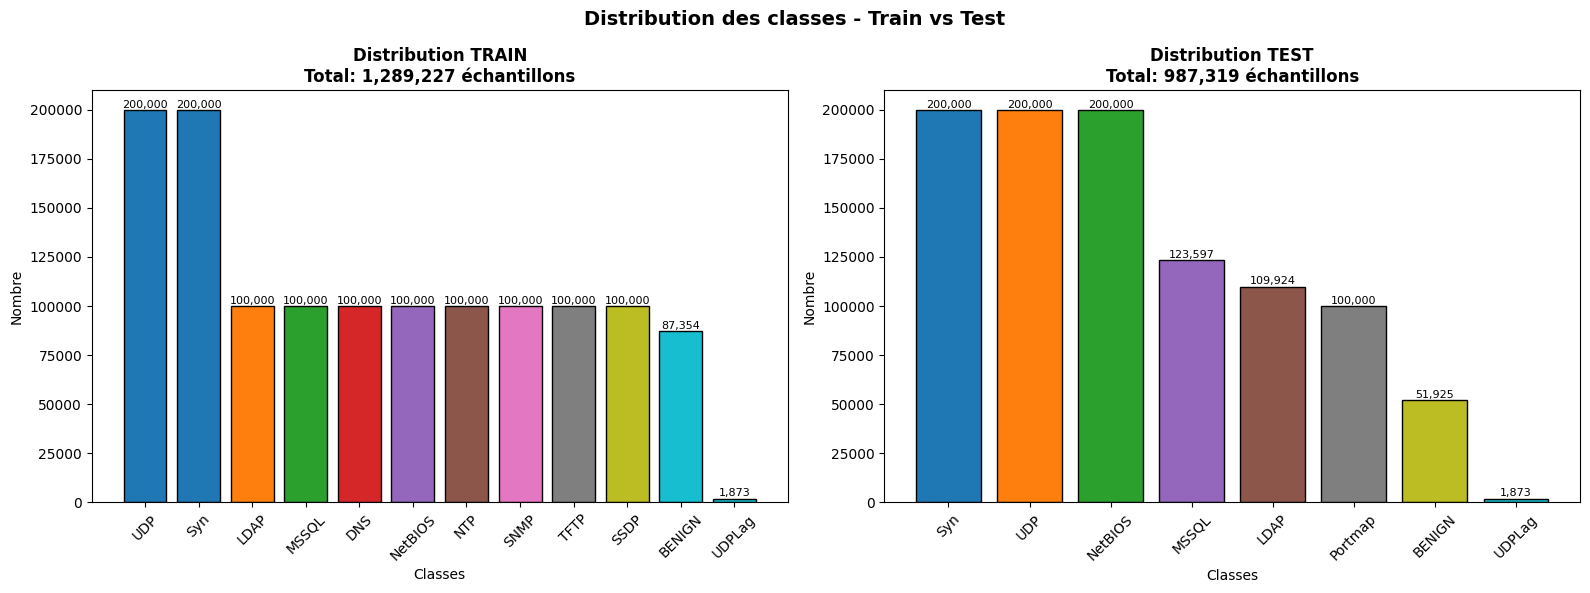

In [6]:
# 2. Créer les graphiques
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Train
train_counts = train_df['Label'].value_counts()
axes[0].bar(train_counts.index, train_counts.values,
            color=plt.cm.tab10(np.linspace(0, 1, len(train_counts))),
            edgecolor='black')
axes[0].set_title(f'Distribution TRAIN\nTotal: {len(train_df):,} échantillons', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Classes', fontsize=10)
axes[0].set_ylabel('Nombre', fontsize=10)
axes[0].tick_params(axis='x', rotation=45)
for i, (label, count) in enumerate(train_counts.items()):
    axes[0].text(i, count + 100, f'{count:,}', ha='center', va='bottom', fontsize=8)

# Test
test_counts = test_df['Label'].value_counts()
axes[1].bar(test_counts.index, test_counts.values,
            color=plt.cm.tab10(np.linspace(0, 1, len(test_counts))),
            edgecolor='black')
axes[1].set_title(f'Distribution TEST\nTotal: {len(test_df):,} échantillons', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Classes', fontsize=10)
axes[1].set_ylabel('Nombre', fontsize=10)
axes[1].tick_params(axis='x', rotation=45)
for i, (label, count) in enumerate(test_counts.items()):
    axes[1].text(i, count + 100, f'{count:,}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Distribution des classes - Train vs Test', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# suppression des colonnes d'identification dans train et test
cols_suppr = [
    "Flow ID",
    'Fwd Header Length.1',
    "Source IP",
    "Source Port",
    "Destination IP",
   # "Destination Port",
    "Timestamp",
    "Unnamed: 0",
    "SimillarHTTP",           #  Colonnes d'identification
    "Inbound",                #  capturé de manière incohérente peut fausser le modele

]
train_df.drop(columns=cols_suppr, inplace=True, errors='ignore')
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)

# taille de chaque fichier apres suppression des colonnes d'identification dans train et test
train_df.shape

(1289227, 79)

In [14]:
# taille de chaque fichier
train_df.shape, test_df.shape

((1289227, 79), (987319, 80))

In [15]:
# appercu du fichier train
train_df.head()

,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,5165,17,214842,6,0,2088.0,0.0,393.0,321.0,348.0,...,321,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,UDP
1,443,6,20824,1,3,0.0,62.0,0.0,0.0,0.0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
2,25920,17,1,2,0,890.0,0.0,445.0,445.0,445.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MSSQL
3,47896,17,12127,108,0,47520.0,0.0,440.0,440.0,440.0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NTP
4,31610,17,105226,4,0,1438.0,0.0,389.0,330.0,359.5,...,330,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,UDP


In [16]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1289227 entries, 0 to 1289226
Data columns (total 79 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   Destination Port             1289227 non-null  int64  
 1   Protocol                     1289227 non-null  int64  
 2   Flow Duration                1289227 non-null  int64  
 3   Total Fwd Packets            1289227 non-null  int64  
 4   Total Backward Packets       1289227 non-null  int64  
 5   Total Length of Fwd Packets  1289227 non-null  float64
 6   Total Length of Bwd Packets  1289227 non-null  float64
 7   Fwd Packet Length Max        1289227 non-null  float64
 8   Fwd Packet Length Min        1289227 non-null  float64
 9   Fwd Packet Length Mean       1289227 non-null  float64
 10  Fwd Packet Length Std        1289227 non-null  float64
 11  Bwd Packet Length Max        1289227 non-null  float64
 12  Bwd Packet Length Min        1289227 non-n

## Data Preprocessing

In [17]:
# Vérifier la distribution de la variable cible dans les données d'entraînement
train_df["Label"].value_counts()

,count
Label,
UDP,200000
Syn,200000
NTP,100000
MSSQL,100000
TFTP,100000
LDAP,100000
SNMP,100000
NetBIOS,100000
SSDP,100000


In [18]:
# Vérifier la distribution de la variable cible dans les données test
test_df["Label"].value_counts()

,count
Label,
Syn,200000
UDP,200000
NetBIOS,200000
MSSQL,123597
LDAP,109924
Portmap,100000
BENIGN,51925
UDPLag,1873


Les valeurs de la colonne cible ne correspondent pas entre les données d'entraînement et de test. Nous allons harmoniser les étiquettes.

In [19]:
label_mapping = {
    'DrDoS_UDP': 'UDP',
    'DrDoS_MSSQL': 'MSSQL',
    'DrDoS_LDAP': 'LDAP',
    'DrDoS_NetBIOS': 'NetBIOS',
    'DrDoS_NTP': 'NTP',
    'DrDoS_SSDP': 'SSDP',
    'DrDoS_SNMP': 'SNMP',
    'DrDoS_DNS': 'DNS',
    'UDP-lag': 'UDPLag',
    'TFTP': 'TFTP',
    'Syn': 'Syn',
    'Portmap': 'Portmap',
    'BENIGN': 'BENIGN',
    'Benign': 'BENIGN'
}

train_df['Label'] = train_df['Label'].map(label_mapping).fillna(train_df['Label'])
test_df['Label'] = test_df['Label'].map(label_mapping).fillna(test_df['Label'])

# 2. Garder les classes communes
common_labels = set(train_df['Label'].unique()) & set(test_df['Label'].unique())
print(f"Classes communes : {common_labels}")

# 3. Filtrer
train_df = train_df[train_df['Label'].isin(common_labels)]
test_df = test_df[test_df['Label'].isin(common_labels)]


Classes communes : {'Syn', 'LDAP', 'UDP', 'MSSQL', 'UDPLag', 'BENIGN', 'NetBIOS'}


In [20]:
# # Vérifier la distribution de wla variable cible dans les données de test apres mappage
test_df["Label"].value_counts()

,count
Label,
Syn,200000
UDP,200000
NetBIOS,200000
MSSQL,123597
LDAP,109924
BENIGN,51925
UDPLag,1873


In [21]:
# # Vérifier la distribution de la variable cible dans les données d'entraînement apres mappage
train_df["Label"].value_counts()

,count
Label,
UDP,200000
Syn,200000
MSSQL,100000
NetBIOS,100000
LDAP,100000
BENIGN,87354
UDPLag,1873


In [22]:
classes_a_garder = ['MSSQL', 'UDP','BENIGN','NetBIOS','Syn', 'LDAP']

# 2. Filtrer
train_df = train_df[train_df['Label'].isin(classes_a_garder)]
test_df = test_df[test_df['Label'].isin(classes_a_garder)]

In [23]:
#Afficher les colonnes des données d'entraînement
train_df.columns

Index(['Destination Port', 'Protocol', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       

In [24]:
# Mapping des ports
port_mapping = {'LDAP': 389, 'MSSQL': 1434, 'NetBIOS': 137}
# Nettoyer les noms de colonnes
train_df.columns = train_df.columns.str.strip()
test_df.columns = test_df.columns.str.strip()

# Fonction pour créer la colonne Destination Port
def create_destination_port(df):
    df_copy = df.copy()
    if 'Destination Port' not in df_copy.columns:
        df_copy['Destination Port'] = 0
    for service, port in port_mapping.items():
        mask = df_copy['Label'] == service
        if mask.any():
            df_copy.loc[mask, 'Destination Port'] = port
            print(f"    {service} → {port} : {mask.sum():,} lignes")
    return df_copy

# Application
print("\n Train :")
train_df = create_destination_port(train_df)

print("\n Test :")
test_df = create_destination_port(test_df)



 Train :
    LDAP → 389 : 100,000 lignes
    MSSQL → 1434 : 100,000 lignes
    NetBIOS → 137 : 100,000 lignes

 Test :
    LDAP → 389 : 109,924 lignes
    MSSQL → 1434 : 123,597 lignes
    NetBIOS → 137 : 200,000 lignes


In [25]:
# Afficher les ports par classe
for cls in train_df['Label'].unique():
    print(f"\n {cls}:\n{train_df[train_df['Label'] == cls]['Destination Port'].value_counts().head(10)}")


 UDP:
Destination Port
137      522
80       195
49153    189
22       108
27782     36
36214     34
5757      34
33799     34
7318      34
39500     33
Name: count, dtype: int64

 BENIGN:
Destination Port
53      29606
443     26478
80      11865
0        2119
465       433
22        300
67        251
21        236
5355      110
138        70
Name: count, dtype: int64

 MSSQL:
Destination Port
1434    100000
Name: count, dtype: int64

 Syn:
Destination Port
19362    15
50845    15
12944    14
11275    14
63680    13
4697     13
13521    13
11468    13
24327    13
48227    12
Name: count, dtype: int64

 LDAP:
Destination Port
389    100000
Name: count, dtype: int64

 NetBIOS:
Destination Port
137    100000
Name: count, dtype: int64


In [26]:
# Afficher les colonnes avec une seule valeur unique
for i in train_df.columns:
    if train_df[i].nunique() == 1:
        print(i)

Bwd PSH Flags
Fwd URG Flags
Bwd URG Flags
FIN Flag Count
PSH Flag Count
ECE Flag Count
Fwd Avg Bytes/Bulk
Fwd Avg Packets/Bulk
Fwd Avg Bulk Rate
Bwd Avg Bytes/Bulk
Bwd Avg Packets/Bulk
Bwd Avg Bulk Rate


In [27]:
# Trouver les colonnes avec une seule valeur unique
colonnes_valeur_unique = [col for col in train_df.columns if train_df[col].nunique() == 1]
print(f"Colonnes avec une seule valeur : {colonnes_valeur_unique}")
#Supprimer les colonnes à valeur unique
train_df = train_df.drop(columns=colonnes_valeur_unique)
test_df = test_df.drop(columns=colonnes_valeur_unique)

Colonnes avec une seule valeur : ['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'FIN Flag Count', 'PSH Flag Count', 'ECE Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']


#### Identifier les colonnes catégorielles, les colonnes numériques

In [28]:
SEUIL = 10

cat_cols = ([col for col in train_df.columns if train_df[col].dtypes == "O"] +
            [col for col in train_df.columns if train_df[col].nunique() < SEUIL and train_df[col].dtypes != "O"])

num_cols = [col for col in train_df.columns if train_df[col].dtypes != "O" and train_df[col].nunique() >= SEUIL]

print(f"Catégorielles : {len(cat_cols)}")
print(f"Numériques   : {len(num_cols)}")

Catégorielles : 8
Numériques   : 59


# valeurs infinie

In [29]:
# analyse des valeurs infinies
np.isinf(train_df.select_dtypes(include=np.number)).values.sum()

np.int64(0)

### valeurs manquantes

In [30]:
# Nombre total de valeurs manquantes
train_df.isnull().sum().sum()


np.int64(0)

In [31]:
#train_df = train_df.replace([np.inf, -np.inf], np.nan)
#train_df = train_df.dropna()

### Lignes dupliquées

In [32]:
print(f" Nombre de lignes dupliquées : {train_df.duplicated().sum()}")

 Nombre de lignes dupliquées : 300261


In [33]:
# Supprimer les lignes dupliquées
train_df = train_df.replace([np.inf, -np.inf], np.nan)
train_df = train_df.dropna()
train_df = train_df.drop_duplicates()

# Exploratory Data Analysis (EDA)


### Colonnes catégorielles


 Statistiques de Label :
Label
UDP        197636
Syn        183239
BENIGN      80770
MSSQL       12863
NetBIOS      8948
LDAP         3637
Name: count, dtype: int64

Pourcentage :
Label
UDP        40.574593
Syn        37.618894
BENIGN     16.582049
MSSQL       2.640769
NetBIOS     1.837021
LDAP        0.746675
Name: proportion, dtype: float64


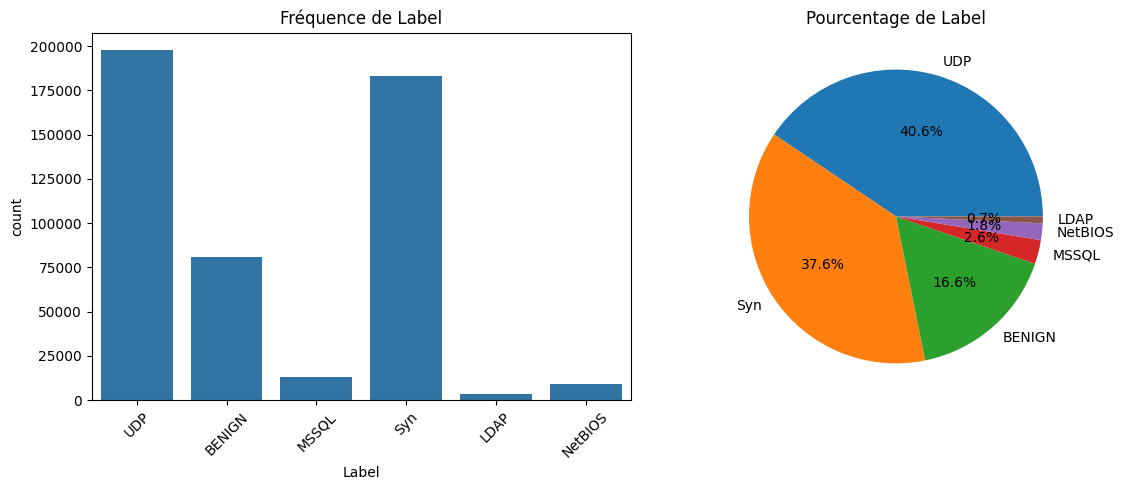

In [34]:
def analyser_colonne_cat(donnees, colonne):

    # Afficher les statistiques
    print(f"\n Statistiques de {colonne} :")
    print(donnees[colonne].value_counts())
    print("\nPourcentage :")
    print(donnees[colonne].value_counts(normalize=True) * 100)

    # Afficher les graphiques
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Diagramme à barres
    sns.countplot(x=colonne, data=donnees, ax=axes[0])
    axes[0].set_title(f'Fréquence de {colonne}')
    axes[0].tick_params(axis='x', rotation=45)

    # Diagramme circulaire
    valeurs = donnees[colonne].value_counts()
    axes[1].pie(valeurs, labels=valeurs.index, autopct='%1.1f%%')
    axes[1].set_title(f'Pourcentage de {colonne}')

    plt.tight_layout()
    plt.show()

analyser_colonne_cat(train_df, 'Label')

# Analyser toutes les colonnes catégorielles
#for col in cat_cols:
    #analyser_colonne_cat(train_df, col)

for col in train_df.columns:
    if col != 'Label' and train_df[col].dtype in ['int64', 'float32']:
        print(f'ANALYSE DE {col}')
        print(train_df.groupby('Label')[col].mean().sort_values(ascending=False))

Afin de compléter notre analyse exploratoire et d'identifier de façon rigoureuse les variables les plus pertinentes pour la classification, nous allons appliquer la méthode de la Mutual Information. Contrairement à la corrélation de Pearson qui ne capture que les relations linéaires, la Mutual Information mesure toute forme de dépendance entre une variable et le label, qu'elle soit linéaire ou non. Pour chaque variable, elle répond à la question suivante : est-ce que connaître la valeur de cette variable me permet de mieux prédire la classe du flux réseau ? Un score de zéro signifie que la variable n'apporte aucune information sur le label, et plus le score est élevé, plus la variable est discriminante. Nous allons ainsi obtenir un classement objectif des 15 meilleures variables de notre dataset."

In [35]:
def plot_boxplot(variable, df):
    plt.figure(figsize=(12, 6))
    sns.boxplot(x="Label", y=variable, data=df)
    plt.yscale('log')
    plt.title(f"Distribution de {variable}", fontsize=14, fontweight='bold')
    plt.xlabel("Type de trafic")
    plt.ylabel(variable)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

###  Flow Duration = Le temps total pendant lequel un flux réseau a été actif (du premier paquet au dernier paquet)

In [36]:
stats_secondes = train_df.groupby('Label')['Flow Duration'].describe()
stats_secondes

,count,mean,std,min,25%,50%,75%,max
Label,,,,,,,,
BENIGN,80770.0,1.193741e+07,3.263796e+07,1.0,1430.25,21150.0,136452.0,119998742.0
LDAP,3637.0,1.544466e+04,3.151517e+05,1.0,1.00,31.0,62.0,9146139.0
MSSQL,12863.0,1.039555e+05,2.097194e+06,1.0,1.00,2.0,46.0,119151083.0
NetBIOS,8948.0,8.283126e+04,2.032438e+06,1.0,1.00,2.0,47.0,119708369.0
Syn,183239.0,2.323325e+07,2.564599e+07,1.0,49.00,127.0,48700435.5,110709420.0
UDP,197636.0,1.291644e+05,1.533193e+06,1.0,1.00,14778.0,108899.0,119999958.0


In [37]:
#duree= test_df.groupby('Label')['Flow Duration'].describe()
#duree

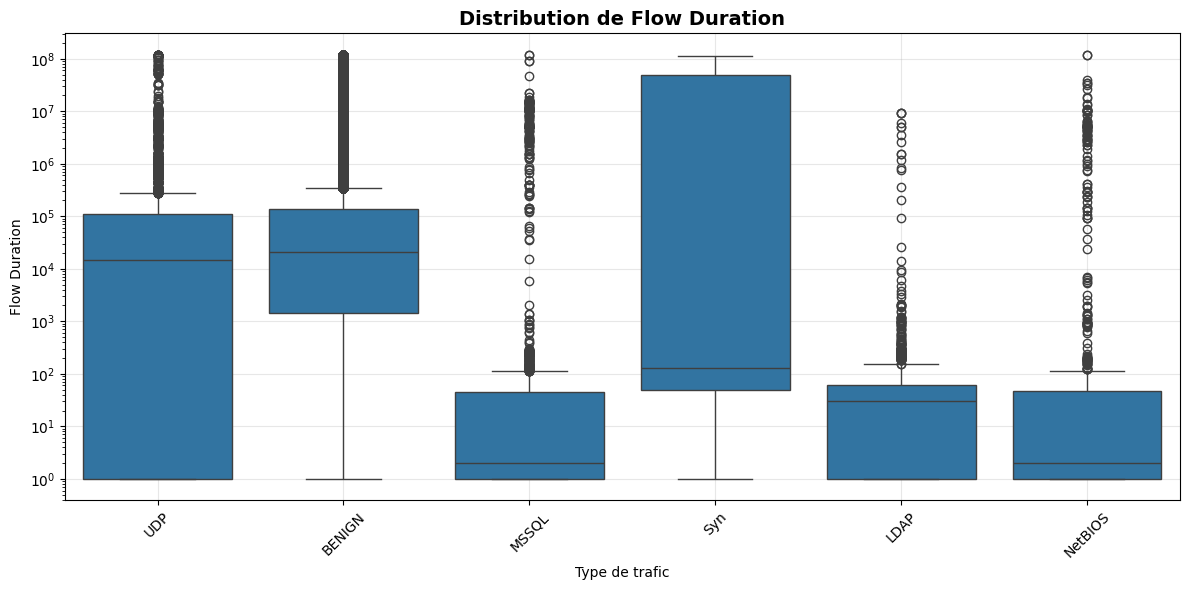

In [38]:
plot_boxplot('Flow Duration', train_df)

# analyse de la taille moyenne des paquets par type de trafic : Taille Moyenne des Paquets

In [39]:
AvgPacketSize = train_df.groupby('Label')['Avg Fwd Segment Size'].describe()
AvgPacketSize

,count,mean,std,min,25%,50%,75%,max
Label,,,,,,,,
BENIGN,80770.0,44.738507,95.793022,0.0,0.0,31.0,43.0,3015.290539
LDAP,3637.0,1395.341179,199.315743,0.0,1424.0,1464.0,1472.0,1472.000000
MSSQL,12863.0,672.947760,325.697460,0.0,456.0,552.0,732.0,1472.000000
NetBIOS,8948.0,568.342711,243.823792,0.0,434.0,506.0,646.0,1472.000000
Syn,183239.0,6.160660,8.878332,0.0,6.0,6.0,6.0,579.000000
UDP,197636.0,390.254403,154.065378,0.0,349.5,364.5,383.0,1472.000000


In [40]:
#plot_boxplot('Avg Packet Size', train_df)

# Fwd Packets Length Total :le volume total d'octets envoyés dans un flux réseau, du client vers le serveur.

In [41]:
#FwdPacketsLengthTotal = train_df.groupby('Label')['Fwd Packets Length Total'].describe()
#FwdPacketsLengthTotal

In [42]:
#plot_boxplot('Fwd Packets Length Total', train_df)

# Fwd Packets/s : C'est le rythme d'envoi des paquets, combien de paquets partent vers la victime chaque seconde.

In [43]:
FwdPackets = train_df.groupby('Label')['Fwd Packets/s'].describe()
FwdPackets


,count,mean,std,min,25%,50%,75%,max
Label,,,,,,,,
BENIGN,80770.0,1.057383e+05,378563.790660,0.008480,19.745467,95.265314,2.532848e+03,3000000.0
LDAP,3637.0,6.964911e+05,827862.249357,0.799132,35714.285714,71428.571429,2.000000e+06,2000000.0
MSSQL,12863.0,1.051067e+06,839088.904709,0.043772,43478.260870,1000000.000000,2.000000e+06,2000000.0
NetBIOS,8948.0,1.130699e+06,874577.752597,0.113863,42553.191489,1000000.000000,2.000000e+06,2000000.0
Syn,183239.0,3.802390e+05,759694.339797,0.061198,0.196736,15748.031496,4.081633e+04,2000000.0
UDP,197636.0,7.212985e+05,883262.665699,0.034280,36.734319,763.407493,2.000000e+06,2000000.0


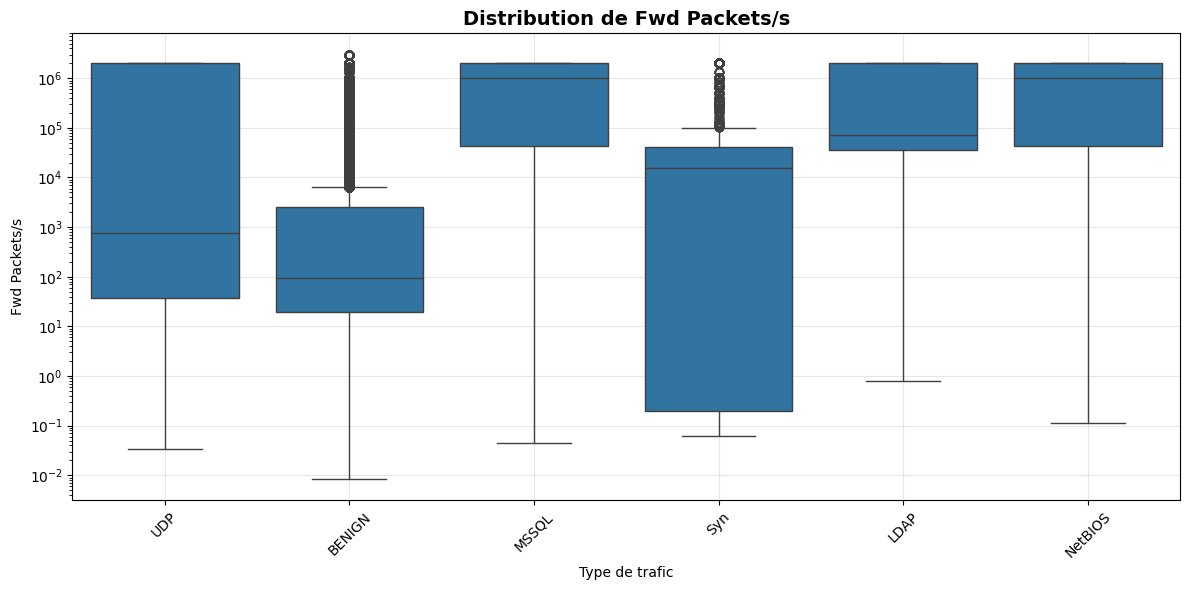

In [44]:
plot_boxplot('Fwd Packets/s', train_df)


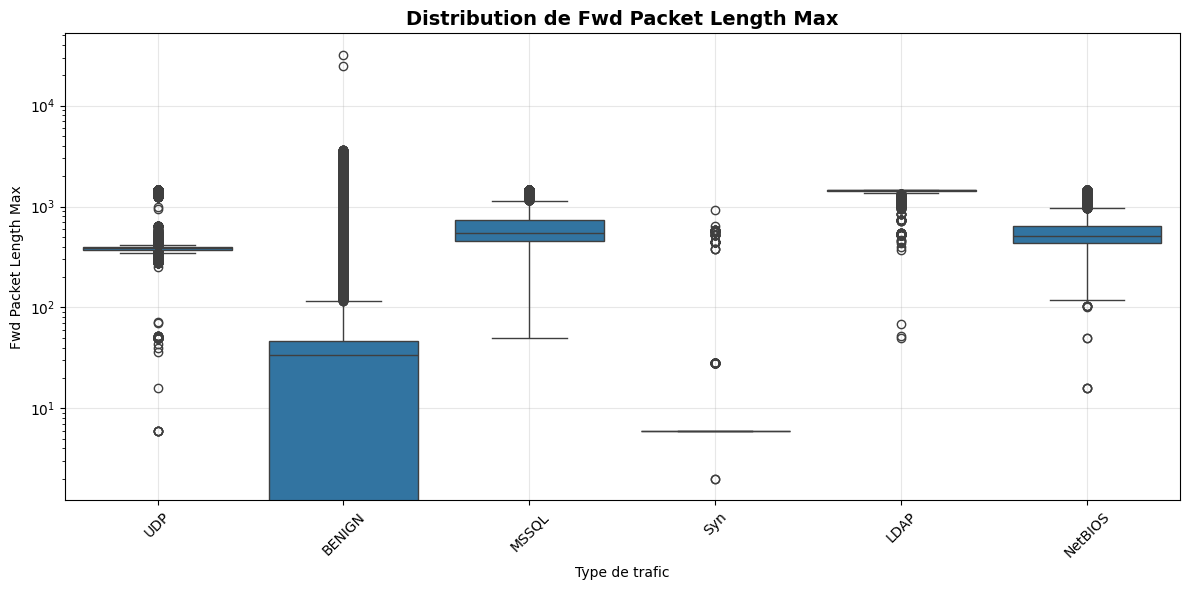

In [45]:
plot_boxplot('Fwd Packet Length Max', train_df)


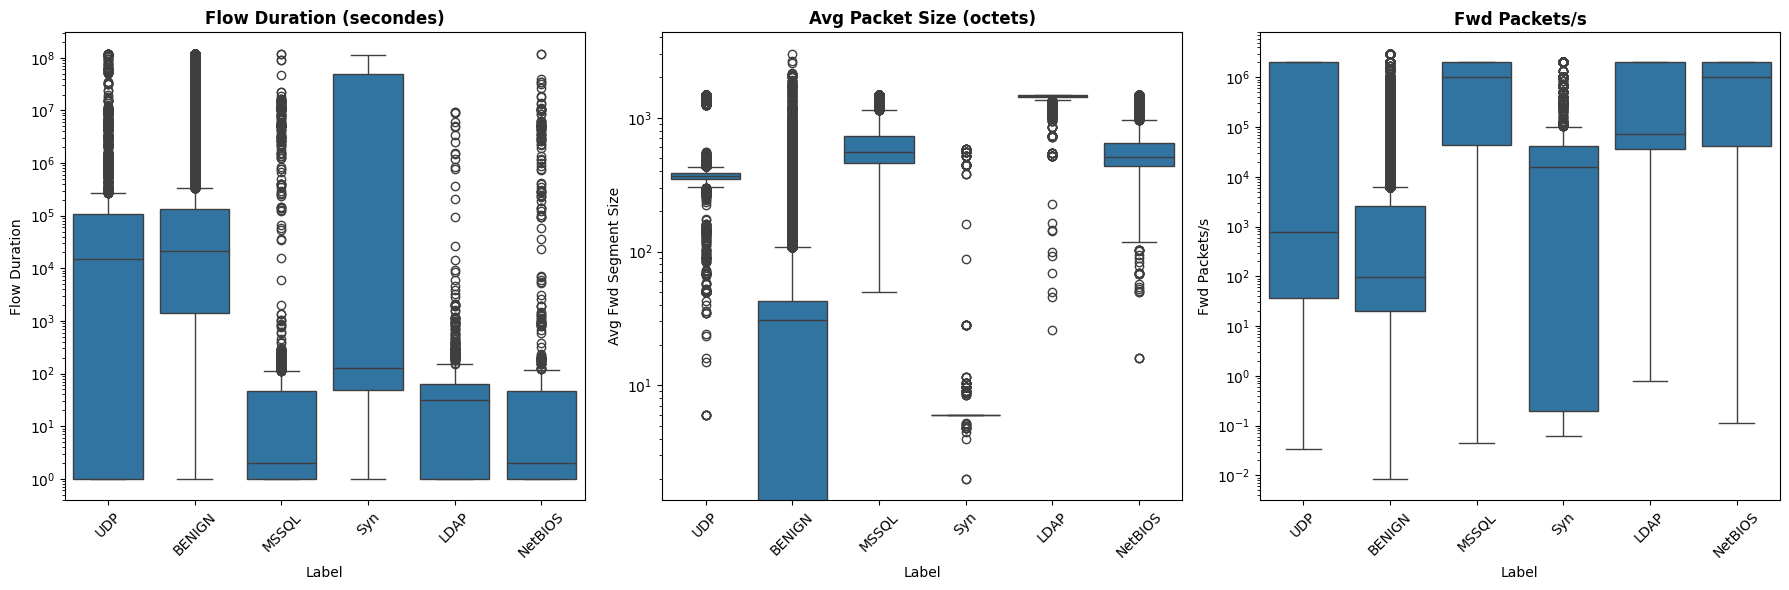

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Créer une figure avec 3 sous-graphiques
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Flow Duration
sns.boxplot(x='Label', y='Flow Duration', data=train_df, ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Flow Duration (secondes)', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# 2. Avg Packet Size
sns.boxplot(x='Label', y='Avg Fwd Segment Size', data=train_df, ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('Avg Packet Size (octets)', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

# 3. Fwd Packets/s
sns.boxplot(x='Label', y='Fwd Packets/s', data=train_df, ax=axes[2])
axes[2].set_yscale('log')
axes[2].set_title('Fwd Packets/s', fontsize=12, fontweight='bold')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [47]:
# Ajouter les ports
#port_mapping = {
#   'LDAP': 389, 'MSSQL': 1434, 'NetBIOS': 137,
#  'DNS': 53, 'UDP': 53, 'Syn': 80, 'BENIGN': 0
#}

#train_df['Dst Port'] = train_df['Label'].map(port_mapping).fillna(0)
#test_df['Dst Port'] = test_df['Label'].map(port_mapping).fillna(0)


### Indicateurs de paquets et motifs d'attaque

MOYENNE DES FLAGS PAR TYPE D'ATTAQUE
         SYN Flag Count  ACK Flag Count
Label                                  
BENIGN         0.002340        0.200990
LDAP           0.000825        0.003299
MSSQL          0.000078        0.003498
NetBIOS        0.000112        0.004694
Syn            0.000082        0.999574
UDP            0.000435        0.002039


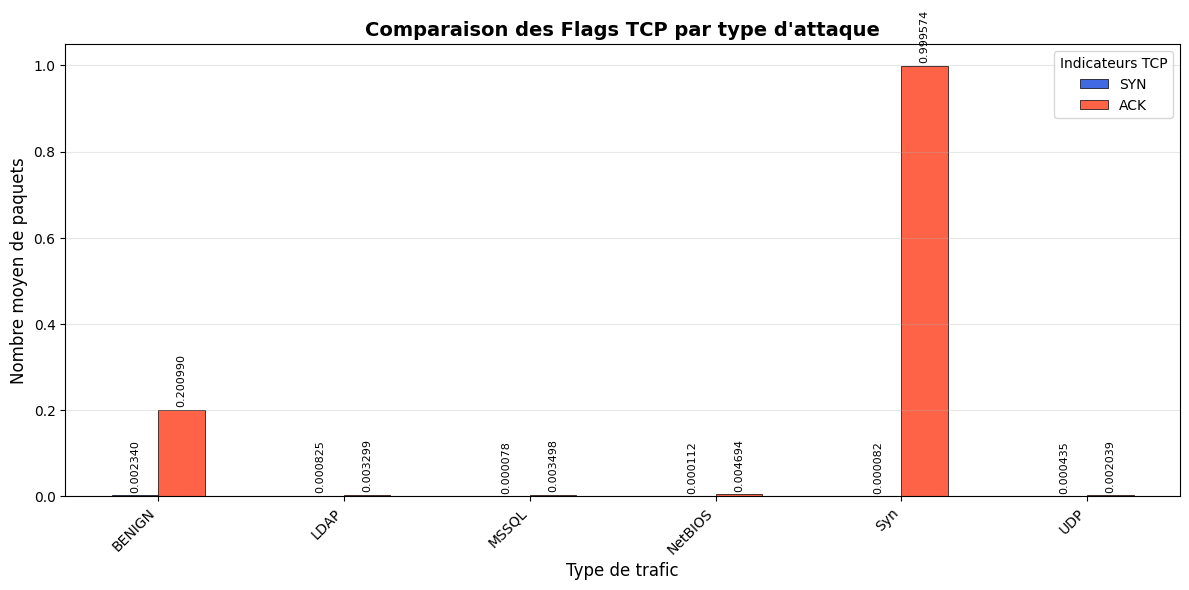

In [48]:
stats = train_df.groupby('Label')[['SYN Flag Count', 'ACK Flag Count']].mean()
print("="*50)
print("MOYENNE DES FLAGS PAR TYPE D'ATTAQUE")
print("="*50)
print(stats)

# Graphique
ax = stats.plot(kind='bar', figsize=(12, 6), color=['royalblue', 'tomato'], edgecolor='black', linewidth=0.5)

plt.title("Comparaison des Flags TCP par type d'attaque", fontsize=14, fontweight='bold')
plt.ylabel("Nombre moyen de paquets", fontsize=12)
plt.xlabel("Type de trafic", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title="Indicateurs TCP", labels=['SYN', 'ACK'])

for container in ax.containers:
    ax.bar_label(container, fmt='%.6f', fontsize=8, rotation=90, padding=2)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [49]:
mask = train_df['Label'] == 'Syn'
train_df.loc[mask, ['SYN Flag Count', 'ACK Flag Count']] = train_df.loc[mask, ['ACK Flag Count', 'SYN Flag Count']].values

mask = test_df['Label'] == 'Syn'
test_df.loc[mask, ['SYN Flag Count', 'ACK Flag Count']] = test_df.loc[mask, ['ACK Flag Count', 'SYN Flag Count']].values


MOYENNE DES FLAGS PAR TYPE D'ATTAQUE
         SYN Flag Count  ACK Flag Count
Label                                  
BENIGN         0.004506        0.198440
LDAP           0.000045        0.000264
MSSQL          0.000049        0.000534
NetBIOS        0.000000        0.000030
Syn            0.999565        0.000075
UDP            0.000000        0.000090


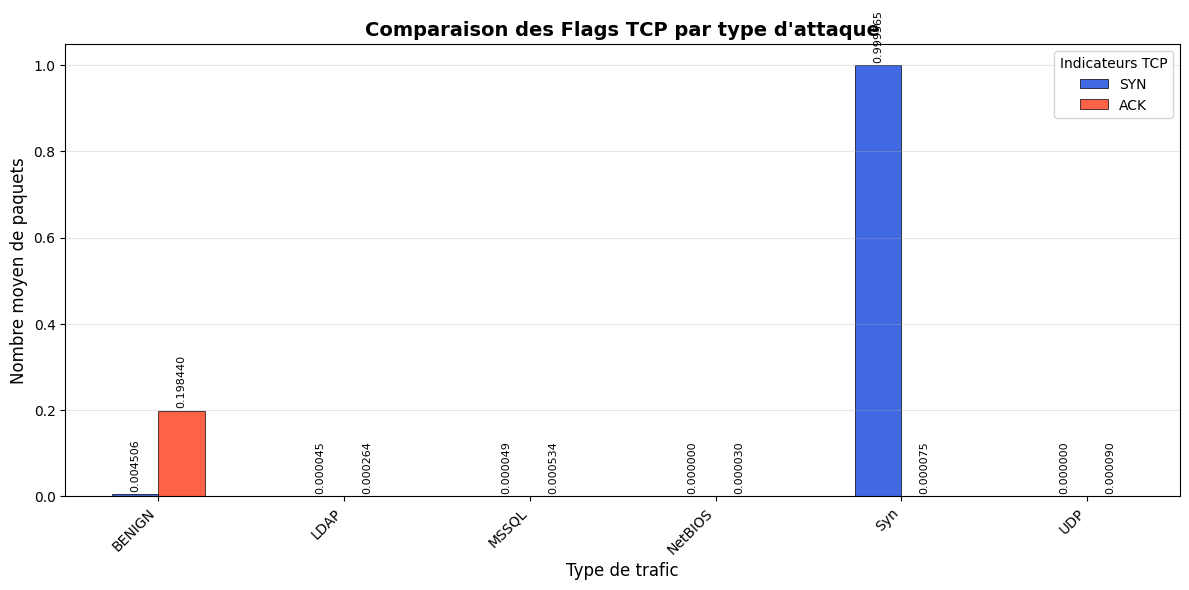

In [50]:
stats = test_df.groupby('Label')[['SYN Flag Count', 'ACK Flag Count']].mean()
print("="*50)
print("MOYENNE DES FLAGS PAR TYPE D'ATTAQUE")
print("="*50)
print(stats)

# Graphique
ax = stats.plot(kind='bar', figsize=(12, 6), color=['royalblue', 'tomato'], edgecolor='black', linewidth=0.5)

plt.title("Comparaison des Flags TCP par type d'attaque", fontsize=14, fontweight='bold')
plt.ylabel("Nombre moyen de paquets", fontsize=12)
plt.xlabel("Type de trafic", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title="Indicateurs TCP", labels=['SYN', 'ACK'])

for container in ax.containers:
    ax.bar_label(container, fmt='%.6f', fontsize=8, rotation=90, padding=2)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Analyse des requêtes provenant de différents protocoles

Tableau croisé : Protocole vs Attaque
Protocol    0       6       17
Label                         
BENIGN    1390   49550   29830
LDAP         3      35    3599
MSSQL        4     107   12752
NetBIOS      2     105    8841
Syn          2  183178      59
UDP         11     763  196862


<Figure size 1200x600 with 0 Axes>

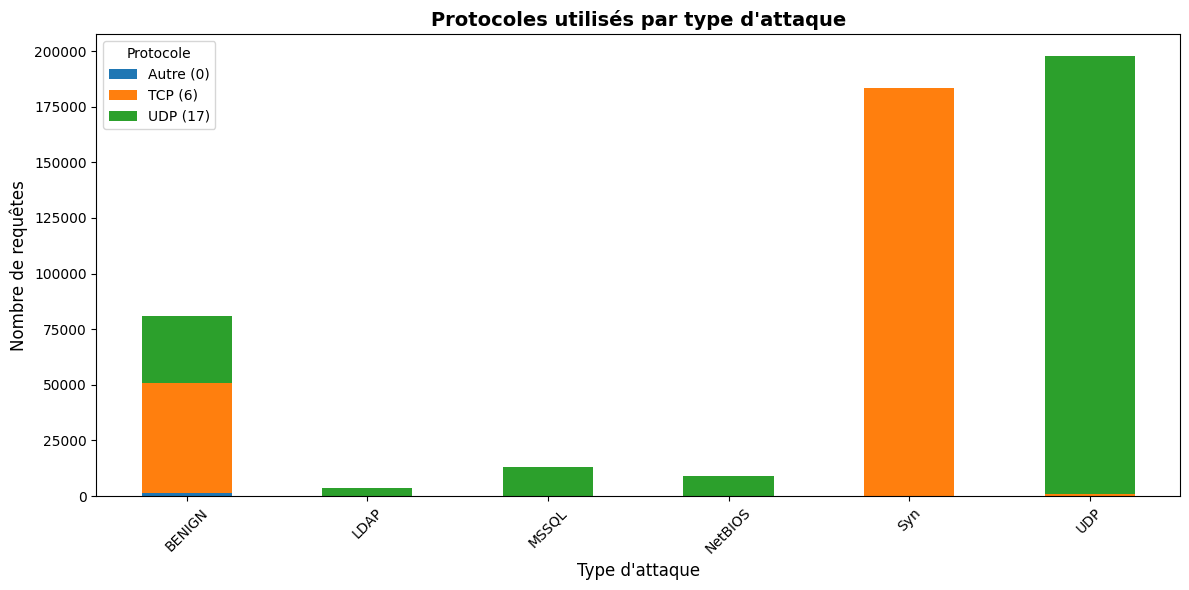

In [51]:
# Créer un tableau
tableau_croise = pd.crosstab(train_df['Label'], train_df['Protocol'])
print("Tableau croisé : Protocole vs Attaque")
print(tableau_croise)
plt.figure(figsize=(12, 6))

# Créer un graphique à barres
tableau_croise.plot(kind='bar', stacked=True, figsize=(12, 6))

plt.title("Protocoles utilisés par type d'attaque", fontsize=14, fontweight='bold')
plt.xlabel("Type d'attaque", fontsize=12)
plt.ylabel("Nombre de requêtes", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Protocole", labels=['Autre (0)', 'TCP (6)', 'UDP (17)'])
plt.tight_layout()
plt.show()


In [52]:
for col in num_cols:
    train_df[col] = train_df[col].astype('float32')
    test_df[col] = test_df[col].astype('float32')

for col in cat_cols:
    train_df[col] = train_df[col].astype('category')
    test_df[col] = test_df[col].astype('category')

In [53]:
# Sélectionner les colonnes numériques
colonnes_numeriques = train_df.select_dtypes(include=[np.number])
# Calculer la matrice de corrélation
matrice_correlation = colonnes_numeriques.corr().abs()
# Seuil de corrélation
SEUIL = 0.8
# Trouver les groupes
groupes = []
colonnes_traitees = set()
for i, col1 in enumerate(colonnes_numeriques.columns):
    if col1 in colonnes_traitees:
        continue
    # Trouver toutes les colonnes corrélées
    groupe = {col1}
    for col2 in colonnes_numeriques.columns:
        if col2 != col1 and col2 not in colonnes_traitees:
            if matrice_correlation.loc[col1, col2] > SEUIL:
                groupe.add(col2)

    if len(groupe) > 1:
        groupes.append(groupe)
        colonnes_traitees.update(groupe)

for i, groupe in enumerate(groupes, 1):
    print(f"\n Groupe {i} ({len(groupe)} variables) :")
    for col in sorted(groupe):
        print(f"   - {col}")


 Groupe 1 (9 variables) :
   - Flow Duration
   - Flow IAT Max
   - Flow IAT Std
   - Fwd IAT Max
   - Fwd IAT Mean
   - Fwd IAT Std
   - Fwd IAT Total
   - Idle Max
   - Idle Mean

 Groupe 2 (2 variables) :
   - Subflow Fwd Packets
   - Total Fwd Packets

 Groupe 3 (4 variables) :
   - Subflow Bwd Bytes
   - Subflow Bwd Packets
   - Total Backward Packets
   - Total Length of Bwd Packets

 Groupe 4 (2 variables) :
   - Subflow Fwd Bytes
   - Total Length of Fwd Packets

 Groupe 5 (5 variables) :
   - Average Packet Size
   - Avg Fwd Segment Size
   - Fwd Packet Length Max
   - Fwd Packet Length Mean
   - Packet Length Mean

 Groupe 6 (2 variables) :
   - Fwd Packet Length Min
   - Min Packet Length

 Groupe 7 (6 variables) :
   - Avg Bwd Segment Size
   - Bwd Packet Length Max
   - Bwd Packet Length Mean
   - Bwd Packet Length Std
   - Max Packet Length
   - Packet Length Std

 Groupe 8 (2 variables) :
   - Flow Packets/s
   - Fwd Packets/s

 Groupe 9 (2 variables) :
   - Flow IAT Mi

### Sélection des Caractéristiques

In [54]:
#  Sélectionner uniquement les colonnes numériques
colonnes_numeriques = train_df.select_dtypes(include=[np.number])
# Calculer la matrice de corrélation
matrice_correlation = colonnes_numeriques.corr().abs()
# Créer un masque pour la partie supérieure de la matrice (corr(A,B) = corr(B,A))
masque = np.triu(np.ones(matrice_correlation.shape), k=1).astype(bool)

triangle_superieur = matrice_correlation.where(masque)
# Trouver les colonnes avec une corrélation >= 0.8
colonnes_fortement_correlees = [
    col for col in triangle_superieur.columns
    if any(triangle_superieur[col] > 0.8)
]
# Afficher les résultats
print(f"Nombre total de colonnes fortement corrélées : {len(colonnes_fortement_correlees)}")
print("Colonnes fortement corrélées :", colonnes_fortement_correlees)

Nombre total de colonnes fortement corrélées : 30
Colonnes fortement corrélées : ['Total Length of Bwd Packets', 'Fwd Packet Length Mean', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow IAT Std', 'Flow IAT Max', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Std', 'Bwd IAT Max', 'Fwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'Active Max', 'Active Min', 'Idle Mean', 'Idle Max', 'Idle Min']


In [55]:
# suppression des colonnes fortement corrélées dans train et test
train_df.drop(colonnes_fortement_correlees, axis=1, inplace=True)
test_df.drop(colonnes_fortement_correlees, axis=1, inplace=True)

In [56]:
# taille du jeu de données après suppression des colonnes fortement corrélées
train_df.shape, test_df.shape

((487093, 37), (885446, 38))

In [57]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 487093 entries, 0 to 1289220
Data columns (total 37 columns):
 #   Column                       Non-Null Count   Dtype   
---  ------                       --------------   -----   
 0   Destination Port             487093 non-null  float32 
 1   Protocol                     487093 non-null  category
 2   Flow Duration                487093 non-null  float32 
 3   Total Fwd Packets            487093 non-null  float32 
 4   Total Backward Packets       487093 non-null  float32 
 5   Total Length of Fwd Packets  487093 non-null  float32 
 6   Fwd Packet Length Max        487093 non-null  float32 
 7   Fwd Packet Length Min        487093 non-null  float32 
 8   Fwd Packet Length Std        487093 non-null  float32 
 9   Bwd Packet Length Max        487093 non-null  float32 
 10  Bwd Packet Length Min        487093 non-null  float32 
 11  Flow Bytes/s                 487093 non-null  float32 
 12  Flow Packets/s               487093 non-null  fl

### Division en ensembles d'entraînement, validation et test


df_total = pd.concat([train_df, test_df], ignore_index=True)

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    df_total.drop('Label', axis=1),
    df_total['Label'],
    test_size=0.2,
    random_state=42,
    stratify=df_total['Label']
)


In [58]:
## Division de l'ensemble d'entraînement (80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(train_df.drop("Label", axis=1), train_df["Label"], test_size=0.2, random_state=42)
#X_train, y_train = train_df.drop("Label", axis=1), train_df["Label"]
#Ensemble de test
X_test, y_test = test_df.drop("Label", axis=1), test_df["Label"]

print(pd.Series(y_train).value_counts())
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [59]:
print(pd.Series(y_train).value_counts())

Label
UDP        157986
Syn        146557
BENIGN      64679
MSSQL       10360
NetBIOS      7192
LDAP         2900
Name: count, dtype: int64


In [60]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 389674 entries, 210011 to 299867
Data columns (total 36 columns):
 #   Column                       Non-Null Count   Dtype   
---  ------                       --------------   -----   
 0   Destination Port             389674 non-null  float32 
 1   Protocol                     389674 non-null  category
 2   Flow Duration                389674 non-null  float32 
 3   Total Fwd Packets            389674 non-null  float32 
 4   Total Backward Packets       389674 non-null  float32 
 5   Total Length of Fwd Packets  389674 non-null  float32 
 6   Fwd Packet Length Max        389674 non-null  float32 
 7   Fwd Packet Length Min        389674 non-null  float32 
 8   Fwd Packet Length Std        389674 non-null  float32 
 9   Bwd Packet Length Max        389674 non-null  float32 
 10  Bwd Packet Length Min        389674 non-null  float32 
 11  Flow Bytes/s                 389674 non-null  float32 
 12  Flow Packets/s               389674 non-null

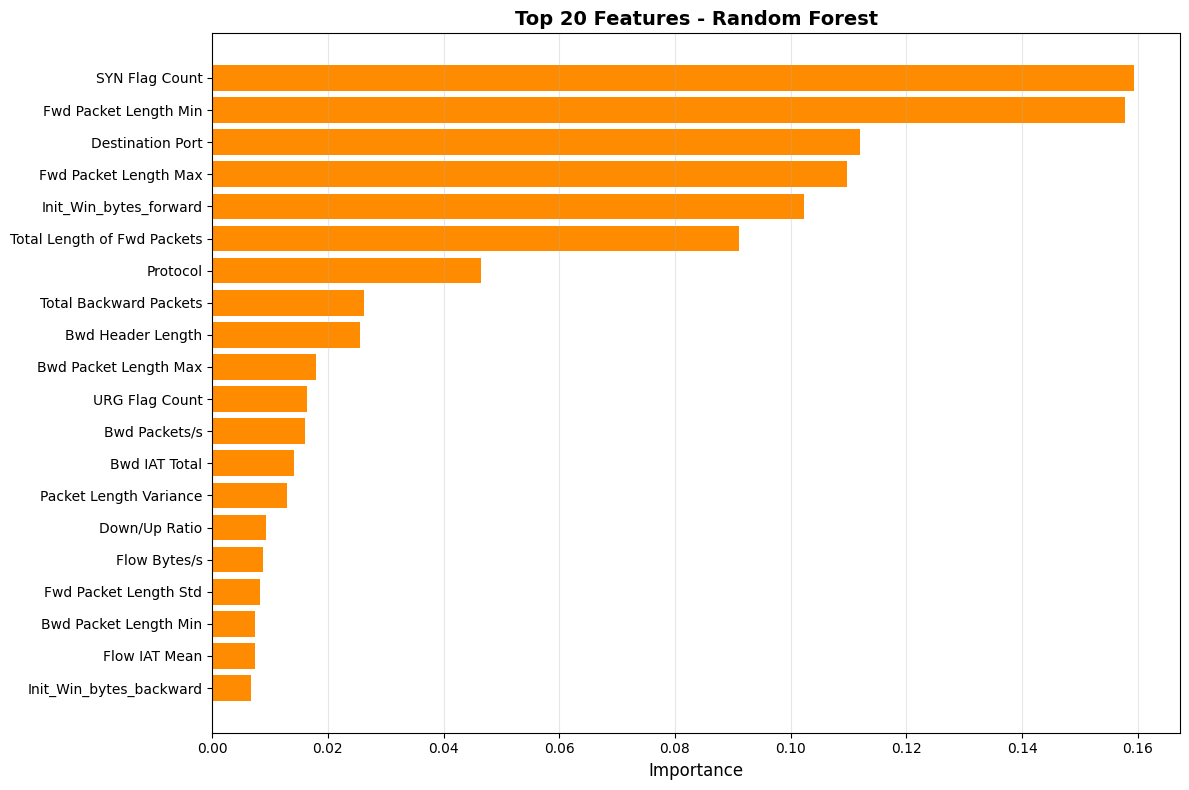

                        Feature  Importance
23               SYN Flag Count    0.159346
7         Fwd Packet Length Min    0.157750
0              Destination Port    0.112052
6         Fwd Packet Length Max    0.109772
29       Init_Win_bytes_forward    0.102284
5   Total Length of Fwd Packets    0.091039
1                      Protocol    0.046493
4        Total Backward Packets    0.026299
20            Bwd Header Length    0.025509
9         Bwd Packet Length Max    0.018023
26               URG Flag Count    0.016411
21                Bwd Packets/s    0.015991
15                Bwd IAT Total    0.014123
22       Packet Length Variance    0.012881
28                Down/Up Ratio    0.009252
11                 Flow Bytes/s    0.008849
8         Fwd Packet Length Std    0.008281
10        Bwd Packet Length Min    0.007432
13                Flow IAT Mean    0.007418
30      Init_Win_bytes_backward    0.006687


In [61]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Importances
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

top20 = importance_df.head(20)

# Graphique
plt.figure(figsize=(12, 8))
plt.barh(top20['Feature'][::-1], top20['Importance'][::-1], color='darkorange')
plt.title('Top 20 Features - Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance', fontsize=12)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print(top20.head(20))

In [62]:

feature_names = train_df.drop('Label', axis=1).columns.tolist()

# 2. Convertir en DataFrame
if isinstance(X_train, np.ndarray):
    X_train = pd.DataFrame(X_train, columns=feature_names)
    X_val = pd.DataFrame(X_val, columns=feature_names)
    X_test = pd.DataFrame(X_test, columns=feature_names)

# 3. Récupérer la liste des features
FEATURES_TOP = top20['Feature'].tolist()
X_train = X_train[FEATURES_TOP]
X_val = X_val[FEATURES_TOP]
X_test = X_test[FEATURES_TOP]

print(f"   X_train : {X_train.shape}")
print(f"   X_val   : {X_val.shape}")
print(f"   X_test  : {X_test.shape}")

   X_train : (389674, 20)
   X_val   : (97419, 20)
   X_test  : (885446, 20)


In [63]:
#for col in X_train.select_dtypes(include=['category']).columns:
#    X_train[col] = X_train[col].astype('int')
#np.isnan(X_train).sum()

In [64]:
#from imblearn.over_sampling import SMOTE
#for col in X_train.select_dtypes(include=['category']).columns:
 #   X_train[col] = X_train[col].astype('int')
#smote = SMOTE(random_state=42)
#X_train, y_train = smote.fit_resample(X_train, y_train)


In [65]:
#for col in X_train.select_dtypes(include=['int']).columns:
#    X_train[col] = X_train[col].astype('category')

# Encodage de la variable cible

In [66]:
### Encodage de la variable cible
import joblib
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val = le.transform(y_val)
y_test = le.transform(y_test)
joblib.dump(le, 'label_encoder_ddos.pkl')
# mappage
label_map = {index: Label for index, Label in enumerate(le.classes_)}
label_map

{0: 'BENIGN', 1: 'LDAP', 2: 'MSSQL', 3: 'NetBIOS', 4: 'Syn', 5: 'UDP'}

# Mise à l'échelle

In [68]:
# Mise à l'échelle des caractéristiques en utilisant MinMaxScaler
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

joblib.dump(scaler, 'scaler_ddos.pkl')

['scaler_ddos.pkl']

# Entraînement et évaluation des modèles

Entraînement:   0%|          | 0/4 [00:00<?, ?it/s]


 Entraînement de Random Forest...


Entraînement:  25%|██▌       | 1/4 [02:51<08:34, 171.38s/it]

   Accuracy : 0.9997 | F1 : 0.9997

 Entraînement de KNN...


Entraînement:  50%|█████     | 2/4 [16:06<17:56, 538.01s/it]

...

   Accuracy : 0.9998 | F1 : 0.9998


Entraînement:   0%|          | 0/1 [00:00<?, ?it/s]


 Entraînement de MLP Simple...


Entraînement: 100%|██████████| 1/1 [11:26<00:00, 686.25s/it]

 Accuracy : 0.9983 | F1 : 0.9983


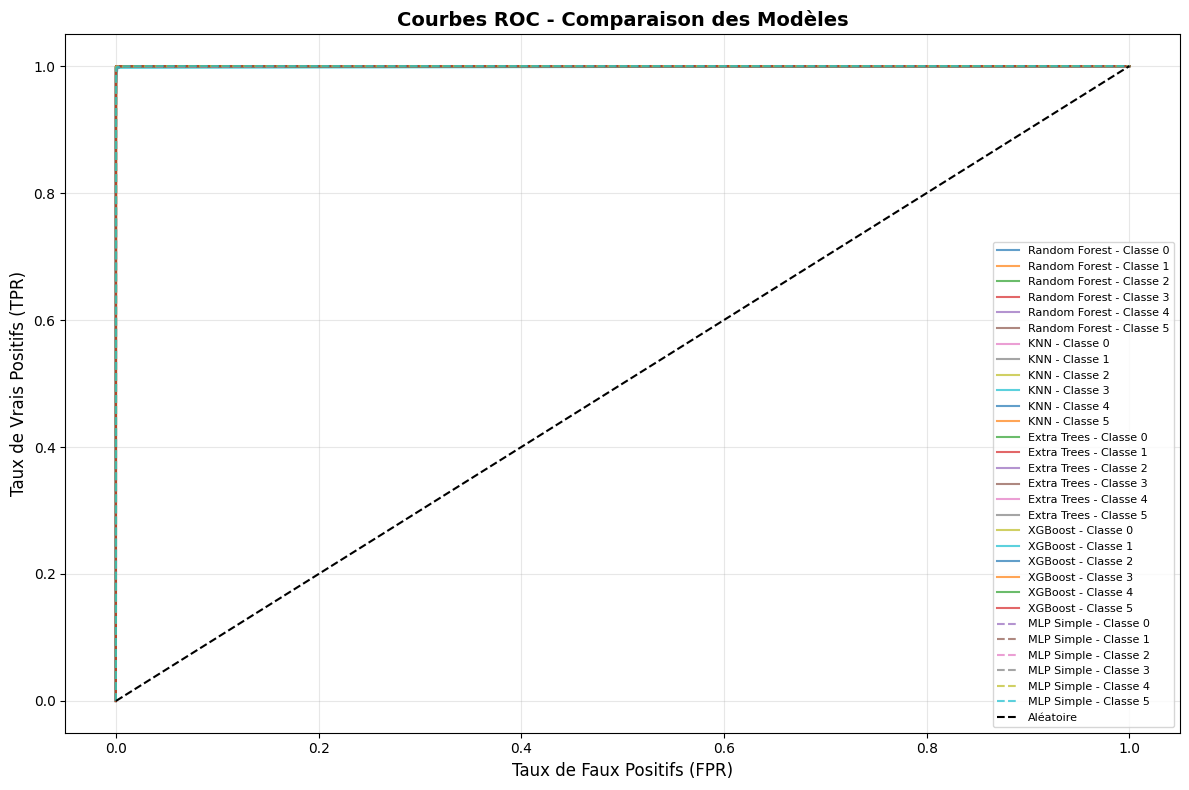

COMPARAISON DES MODÈLES


,Modèle,Accuracy,Precision,Recall,F1 Score,ROC AUC,CV Score
0,Random Forest,0.999700,0.999700,0.999700,0.999700,1.000000,0.999600
1,KNN,0.998000,0.998000,0.998000,0.998000,0.999700,0.997600
2,Extra Trees,0.999600,0.999600,0.999600,0.999600,1.000000,0.999600
3,XGBoost,0.999800,0.999800,0.999800,0.999800,1.000000,0.999800
4,MLP Simple,0.998300,0.998300,0.998300,0.998300,1.000000,0.000000


In [69]:
def train_model(X_train, X_test, y_train, y_test):
    modeles = {
        "Random Forest": RandomForestClassifier(random_state=42),
        "KNN": KNeighborsClassifier( n_neighbors=10),
        "Extra Trees": ExtraTreesClassifier( random_state=42),
        "XGBoost": XGBClassifier(random_state=42,eval_metric="mlogloss")
    }

    # Nombre de classes
    nb_classes = len(np.unique(y_train))
    input_dim = X_train.shape[1]

    # Préparer les données pour Keras (one-hot encoding)
    y_train_keras = to_categorical(y_train, num_classes=nb_classes)
    y_test_keras = to_categorical(y_test, num_classes=nb_classes)

    def create_mlp_simple():
        model = Sequential([
            Input(shape=(input_dim,)),
            Dense(128, activation='relu'),
            Dropout(0.3),
            Dense(64, activation='relu'),
            Dropout(0.3),
            Dense(nb_classes, activation='softmax')
        ])
        model.compile(
            optimizer=Adam(learning_rate=0.001),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
        return model

# entrainement des modeles
    scores_list = []
    modeles_entraines = {}
    predictions = {}
    probabilites = {}

    # Figure ROC
    plt.figure(figsize=(12, 8))

    for nom, modele in tqdm(modeles.items(), desc="Entraînement"):
        print(f"\n Entraînement de {nom}...")
        modele.fit(X_train, y_train)
        modeles_entraines[nom] = modele
        y_pred = modele.predict(X_test)
        y_proba = modele.predict_proba(X_test)
        predictions[nom] = y_pred
        probabilites[nom] = y_proba

        # Métriques
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
        cv = np.mean(cross_val_score(modele, X_train, y_train, cv=5, n_jobs=-1))

        # Courbes ROC
        for i in range(nb_classes):
            fpr, tpr, _ = roc_curve((y_test == i).astype(int), y_proba[:, i])
            plt.plot(fpr, tpr, label=f'{nom} - Classe {i}', alpha=0.7)

        scores_list.append({
            "Modèle": nom,
            "Accuracy": round(accuracy, 4),
            "Precision": round(precision, 4),
            "Recall": round(recall, 4),
            "F1 Score": round(f1, 4),
            "ROC AUC": round(roc_auc, 4),
            "CV Score": round(cv, 4)
        })

        print(f"   Accuracy : {accuracy:.4f} | F1 : {f1:.4f}")

    dl_models = {
        "MLP Simple": create_mlp_simple(),
    }
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True,
        verbose=0
    )

    for nom, modele in tqdm(dl_models.items(), desc="Entraînement"):
        print(f"\n Entraînement de {nom}...")
        history = modele.fit(
            X_train, y_train_keras,
            validation_split=0.2,
            epochs=100,
            batch_size=128,
            callbacks=[early_stop],
            verbose=0
        )
        modeles_entraines[nom] = modele
        # Prédictions
        y_proba = modele.predict(X_test, verbose=0)
        y_pred = np.argmax(y_proba, axis=1)
        predictions[nom] = y_pred
        probabilites[nom] = y_proba

        # Métriques
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')

        # Courbes ROC
        for i in range(nb_classes):
            fpr, tpr, _ = roc_curve((y_test == i).astype(int), y_proba[:, i])
            plt.plot(fpr, tpr, label=f'{nom} - Classe {i}', alpha=0.7, linestyle='--')

        scores_list.append({
            "Modèle": nom,
            "Accuracy": round(accuracy, 4),
            "Precision": round(precision, 4),
            "Recall": round(recall, 4),
            "F1 Score": round(f1, 4),
            "ROC AUC": round(roc_auc, 4),
            "CV Score": 0
        })

        print(f" Accuracy : {accuracy:.4f} | F1 : {f1:.4f}")
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label="Aléatoire")
    plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
    plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
    plt.title('Courbes ROC - Comparaison des Modèles', fontsize=14, fontweight='bold')
    plt.legend(loc='lower right', fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    scores = pd.DataFrame(scores_list)
    return scores, modeles_entraines, predictions, probabilites
scores, modeles, predictions, probabilites = train_model(X_train, X_val, y_train, y_val)

print("COMPARAISON DES MODÈLES")
display(scores.style.background_gradient(cmap='viridis'))


# Afficher le graphique des scores de précision

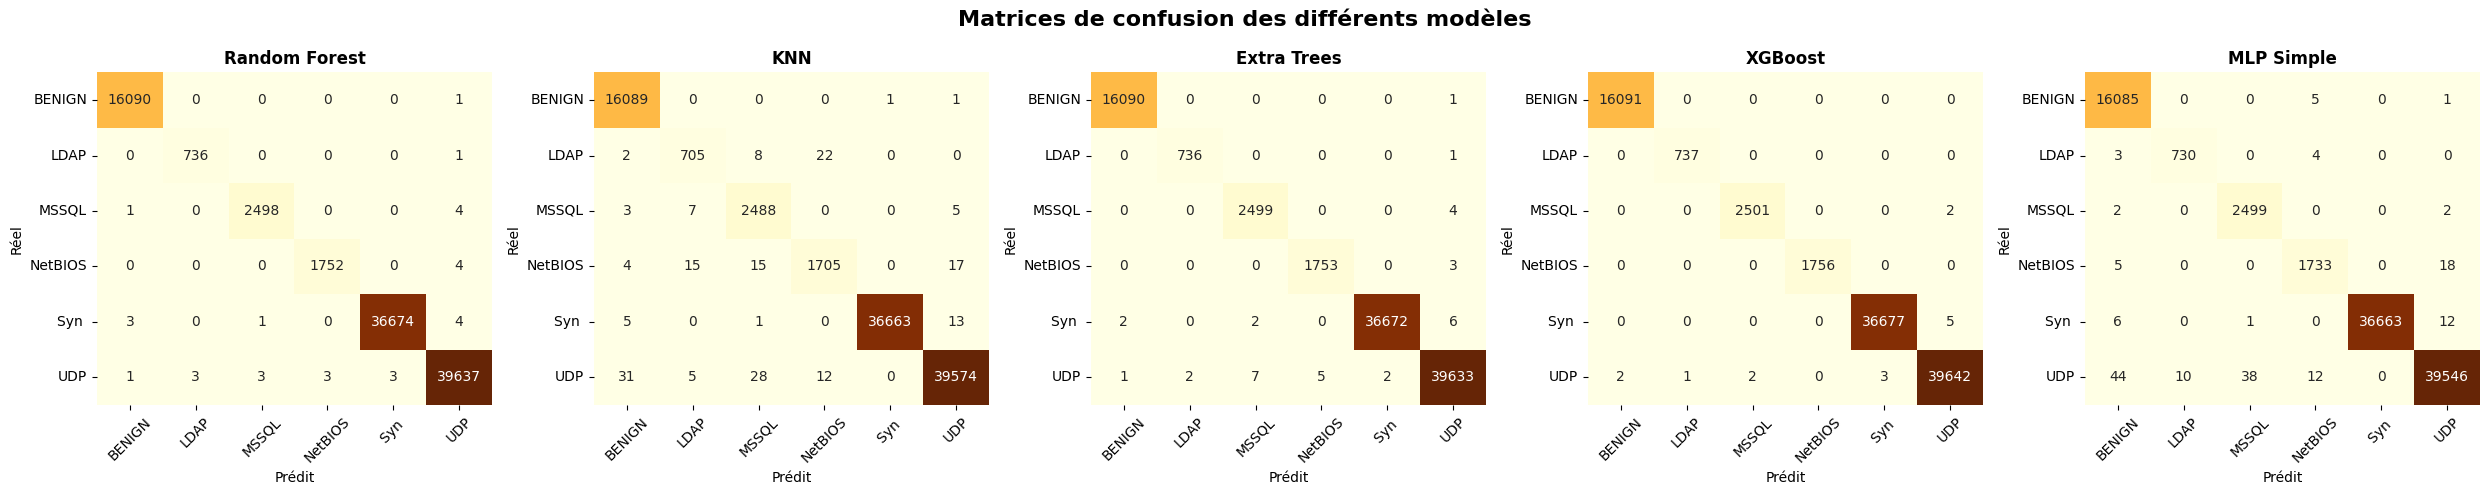

In [70]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
class_names = ['BENIGN', 'LDAP', 'MSSQL', 'NetBIOS',  'Syn ','UDP']
# Création des sous-graphes (1 ligne × 5 colonnes)
fig, axes = plt.subplots(1, len(modeles), figsize=(25,5))
{0: 'BENIGN', 1: 'LDAP', 2: 'MSSQL', 3: 'NetBIOS', 4: 'Syn', 5: 'UDP'}
for ax, (nom, _) in zip(axes, modeles.items()):
    cm = confusion_matrix(y_val, predictions[nom])
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='YlOrBr',
        cbar=False,
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax
    )
    ax.set_title(nom, fontsize=12, fontweight='bold')
    ax.set_xlabel("Prédit")
    ax.set_ylabel("Réel")
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)
plt.suptitle("Matrices de confusion des différents modèles", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

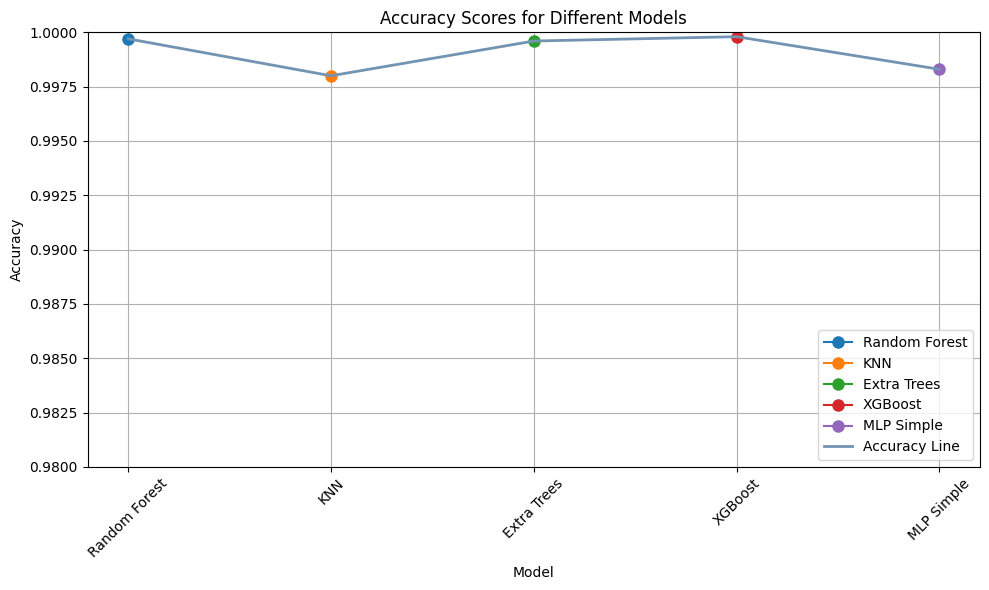

In [71]:
models = scores['Modèle']
accuracy = scores['Accuracy']

plt.figure(figsize=(10, 6))
for i, (model, acc) in enumerate(zip(models, accuracy)):
    plt.plot(model, acc, marker='o',  markersize=8, label=model)

plt.plot(models, accuracy, linestyle='-', color='#7393B3', linewidth=2, label="Accuracy Line")

plt.title("Accuracy Scores for Different Models")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0.98, 1)
plt.xticks(rotation=45)
plt.grid(True)


handles, labels = plt.gca().get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))  # Remove duplicate labels
plt.legend(unique_labels.values(), unique_labels.keys(), loc="lower right")

plt.tight_layout()
plt.show()

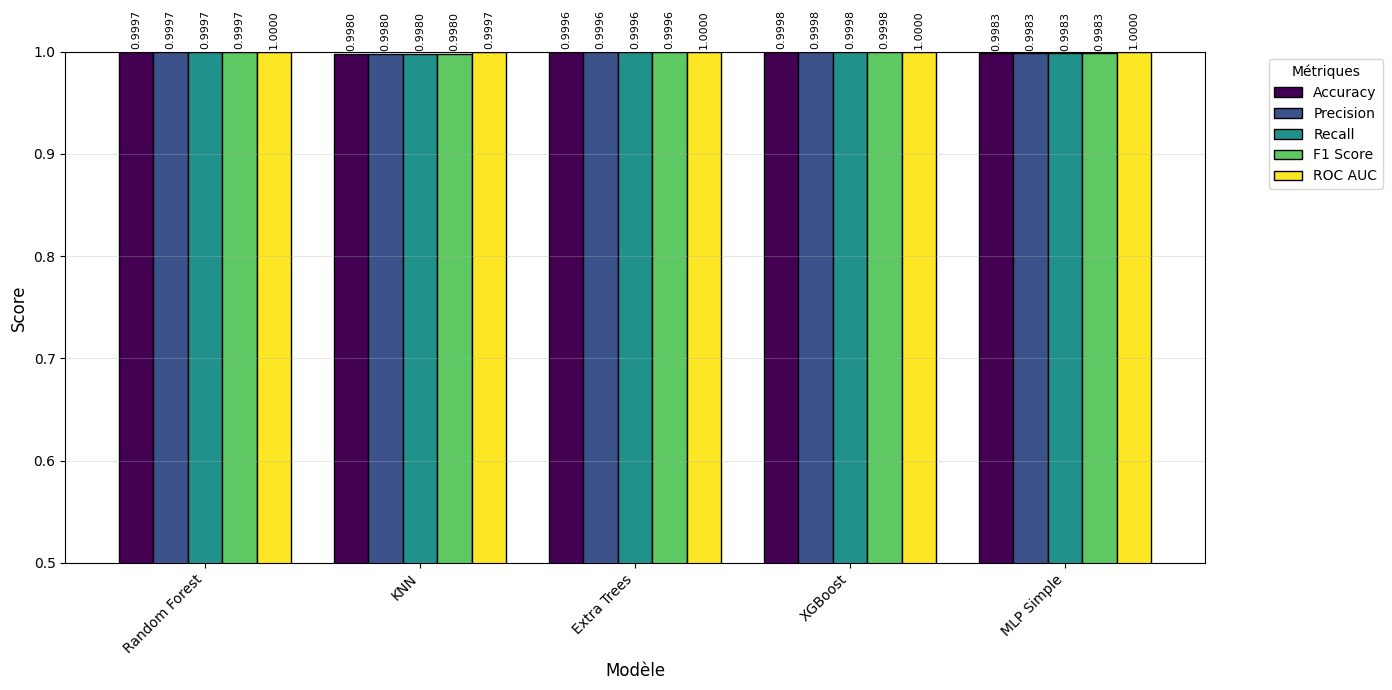

In [72]:
metriques = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']
# Préparer les données
df_plot = scores.set_index('Modèle')[metriques]
# Créer le graphique
fig, ax = plt.subplots(figsize=(14, 7))
# Barres groupées
df_plot.plot(kind='bar', ax=ax, colormap='viridis', edgecolor='black', linewidth=1, width=0.8)
# Ajouter les valeurs sur les barres
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', fontsize=8, rotation=90, padding=2)
#plt.title('Comparaison des 5 métriques des modèles', fontsize=14, fontweight='bold')
plt.xlabel('Modèle', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.ylim(0.5, 1.0)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Métriques', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# évaluation finale sur X_test avec le meilleur modèle

In [ ]:
# 1. Trouver le meilleur modèle
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)
meilleur_idx = scores['Accuracy'].idxmax()
meilleur_nom = scores.loc[meilleur_idx, 'Modèle']
meilleur_modele = modeles[meilleur_nom]

# 2. Prédictions sur le test
y_pred = meilleur_modele.predict(X_test)
y_proba = meilleur_modele.predict_proba(X_test)

# 3. Métriques sur le test
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')

print(f"\nPerformance sur le test :")
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print(f"  ROC AUC   : {roc:.4f}")

# 4. Matrice de confusion
class_names = ['BENIGN', 'LDAP', 'MSSQL', 'NetBIOS','SYN','UDP']
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, linewidths=0.5)
plt.title(f'Matrice de Confusion - {meilleur_nom}', fontsize=14, fontweight='bold')
plt.xlabel('Prédit'), plt.ylabel('Réel'), plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 5. Rapport de classification
print(f"\n Rapport de classification :")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))


In [ ]:
# ============================================================================
# DÉTECTION DDoS AVEC CNN
# ============================================================================

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


# Normaliser les données
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Reshape pour CNN (batch, features, 1)
X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_val_cnn = X_val_scaled.reshape(X_val_scaled.shape[0], X_val_scaled.shape[1], 1)
X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)


# Encoder les labels
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_val_encoded = le.transform(y_val)
y_test_encoded = le.transform(y_test)

nb_classes = len(le.classes_)

# One-hot encoding
y_train_cnn = tf.keras.utils.to_categorical(y_train_encoded, num_classes=nb_classes)
y_val_cnn = tf.keras.utils.to_categorical(y_val_encoded, num_classes=nb_classes)
y_test_cnn = tf.keras.utils.to_categorical(y_test_encoded, num_classes=nb_classes)

# CRÉER LE MODÈLE CNN
def create_cnn_model(input_shape, nb_classes):

    model = Sequential([
        Input(shape=input_shape),
        # Couche 1
        Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        # Couche 2
        Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        # Couche 3
        Conv1D(filters=256, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        # Couche 4
        Conv1D(filters=512, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        # Flatten et couches denses
        Flatten(),
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(256, activation='relu'),
        Dropout(0.3),
        Dense(nb_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

input_shape = (X_train_cnn.shape[1], 1)  # (features, 1)
model = create_cnn_model(input_shape, nb_classes)

model.summary()


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)


history = model.fit(
    X_train_cnn, y_train_cnn,
    validation_data=(X_val_cnn, y_val_cnn),
    epochs=50,
    batch_size=128,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# 5. ÉVALUER LE MODÈLE
# Prédictions
y_pred_proba = model.predict(X_test_cnn)
y_pred = np.argmax(y_pred_proba, axis=1)
y_pred_labels = le.inverse_transform(y_pred)

# Métriques
accuracy = accuracy_score(y_test, y_pred_labels)
print(f"Accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred_labels))

# Historique d'entraînement
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy du CNN', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss du CNN', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matrice de Confusion - CNN', fontsize=14, fontweight='bold')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.tight_layout()
plt.show()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 20, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 20, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 10, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 10, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 5, 256)         │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 5, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 2, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 2, 512)         │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 2, 512)         │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 1, 512)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 916,614 (3.50 MB)

 Trainable params: 914,694 (3.49 MB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/50
3045/3045 ━━━━━━━━━━━━━━━━━━━━ 477s 156ms/step - accuracy: 0.9781 - loss: 0.0623 - val_accuracy: 0.9899 - val_loss: 0.0300 - learning_rate: 0.0010
Epoch 2/50
3045/3045 ━━━━━━━━━━━━━━━━━━━━ 492s 152ms/step - accuracy: 0.9890 - loss: 0.0360 - val_accuracy: 0.9791 - val_loss: 0.0597 - learning_rate: 0.0010
Epoch 3/50
3045/3045 ━━━━━━━━━━━━━━━━━━━━ 453s 149ms/step - accuracy: 0.9907 - loss: 0.0318 - val_accuracy: 0.9943 - val_loss: 0.0201 - learning_rate: 0.0010
Epoch 4/50
3045/3045 ━━━━━━━━━━━━━━━━━━━━ 451s 148ms/step - accuracy: 0.9924 - loss: 0.0267 - val_accuracy: 0.9956 - val_loss: 0.0151 - learning_rate: 0.0010
Epoch 5/50
3045/3045 ━━━━━━━━━━━━━━━━━━━━ 496s 146ms/step - accuracy: 0.9937 - loss: 0.0228 - val_accuracy: 0.9958 - val_loss: 0.0177 - learning_rate: 0.0010
Epoch 6/50
3045/3045 ━━━━━━━━━━━━━━━━━━━━ 514s 150ms/step - accuracy: 0.9938 - loss: 0.0226 - val_accuracy: 0.9922 - val_loss: 0.0222 - learning_rate: 0.0010
Epoch 7/50
3045/3045 ━━━━━━━━━━━━━━━━━━━━ 493s 147ms

# Exporter le meilleur modèle pour le déploiement

In [ ]:

# 7. Sauvegarder
import joblib
#joblib.dump(meilleur_modele, 'meilleur_modele.pkl')
#print(f"\n Modèle sauvegardé : meilleur_modele.pkl")

In [ ]:
#model.save('modele_cnn_ddos.h5')
#print(" Modèle CNN sauvegardé !")

In [ ]:
# 1. Récupérer les noms des colonnes
feature_names = train_df.drop('Label', axis=1).columns.tolist()

# 2. Convertir en DataFrames si nécessaire
if not isinstance(X_train, pd.DataFrame):
    X_train = pd.DataFrame(X_train, columns=feature_names)
    #X_val = pd.DataFrame(X_val, columns=feature_names)
    X_test = pd.DataFrame(X_test, columns=feature_names)

# SELECTKBEST
selector = SelectKBest(f_classif, k=20)
selector.fit(X_train, y_train)
scores = selector.scores_
selected_indices = selector.get_support(indices=True)

df_kbest = pd.DataFrame({
    'Feature': feature_names,
    'Score': scores
}).sort_values('Score', ascending=False)

#  RANDOM FOREST
rf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# SelectKBest
top20_kbest_df = df_kbest.head(20)
axes[0].barh(top20_kbest_df['Feature'][::-1], top20_kbest_df['Score'][::-1], color='steelblue')
axes[0].set_title("SelectKBest - Top 20", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Score F")

# Random Forest
top20_rf_df = importance_df.head(20)
axes[1].barh(top20_rf_df['Feature'][::-1], top20_rf_df['Importance'][::-1], color='darkorange')
axes[1].set_title("Random Forest - Top 20", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()
seuil = 0.05
meilleures_features_rf = importance_df[importance_df["Importance"] >= seuil]["Feature"].tolist()
#X_train = X_train[meilleures_features_rf]
#X_val = X_val[meilleures_features_rf]
#X_test = X_test[meilleures_features_rf]

In [ ]:
# ============================================================================
# ÉVALUATION DU MEILLEUR MODÈLE - CORRIGÉ
# ============================================================================

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             roc_auc_score)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("="*60)
print("📊 ÉVALUATION DU MEILLEUR MODÈLE")
print("="*60)

# ============================================================================
# 1. Trouver le meilleur modèle
# ============================================================================

meilleur_idx = scores['Accuracy'].idxmax()
meilleur_nom = scores.loc[meilleur_idx, 'Modèle']
meilleur_modele = modeles[meilleur_nom]

print(f"✅ Meilleur modèle : {meilleur_nom}")
print(f"   Accuracy (validation) : {scores.loc[meilleur_idx, 'Accuracy']:.4f}")

# ============================================================================
# 2. Vérification des tailles
# ============================================================================

print("\n🔍 Vérification des tailles :")
print(f"   X_test : {X_test.shape[0]}")
print(f"   y_test : {len(y_test)}")

if X_test.shape[0] != len(y_test):
    print("   ⚠️ Tailles différentes ! Alignement...")
    min_len = min(X_test.shape[0], len(y_test))
    X_test = X_test[:min_len]
    y_test = y_test[:min_len]
    print(f"   ✅ Aligné à {min_len} échantillons")

# ============================================================================
# 3. Prédictions
# ============================================================================

print("\n🔄 Prédictions sur le test...")
y_pred = meilleur_modele.predict(X_test)

try:
    y_proba = meilleur_modele.predict_proba(X_test)
    has_proba = True
except:
    has_proba = False
    print("   ⚠️ predict_proba non disponible")

print(f"   ✅ y_pred : {len(y_pred)}")
print(f"   ✅ y_test : {len(y_test)}")

# ============================================================================
# 4. Métriques
# ============================================================================

print("\n" + "="*60)
print("📊 PERFORMANCE SUR LE TEST")
print("="*60)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")

if has_proba:
    try:
        roc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
        print(f"  ROC AUC   : {roc:.4f}")
    except:
        print(f"  ROC AUC   : Non disponible")

# ============================================================================
# 5. Matrice de confusion
# ============================================================================

# Définir les noms des classes
class_names = ['BENIGN', 'LDAP', 'MSSQL', 'NetBIOS', 'SYN', 'UDP']

# Obtenir les classes uniques
unique_classes = sorted(set(y_test) | set(y_pred))
print(f"\n🔍 Classes uniques : {unique_classes}")

# Filtrer les noms des classes
filtered_names = [class_names[i] for i in unique_classes if i < len(class_names)]
print(f"   Noms filtrés : {filtered_names}")

# Si filtered_names est vide, utiliser des noms par défaut
if not filtered_names:
    filtered_names = [f'Classe_{i}' for i in unique_classes]
    print(f"   ⚠️ Noms générés : {filtered_names}")

cm = confusion_matrix(y_test, y_pred, labels=unique_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=filtered_names, yticklabels=filtered_names, linewidths=0.5)
plt.title(f'Matrice de Confusion - {meilleur_nom}', fontsize=14, fontweight='bold')
plt.xlabel('Prédit'), plt.ylabel('Réel'), plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================================================================
# 6. Rapport de classification
# ============================================================================

print(f"\n📊 Rapport de classification :")

# Créer un mapping des classes
class_mapping = {i: class_names[i] if i < len(class_names) else f'Classe_{i}'
                 for i in unique_classes}

# Afficher le rapport
print(classification_report(y_test, y_pred,
                          labels=unique_classes,
                          target_names=[class_mapping[i] for i in unique_classes],
                          digits=4))

# ============================================================================
# 7. Résumé final
# ============================================================================

print("\n" + "="*60)
print("📊 RÉSUMÉ FINAL")
print("="*60)

print(f"""
┌─────────────────────┬────────────────────┐
│ Métrique            │ Valeur             │
├─────────────────────┼────────────────────┤
│ Modèle              │ {meilleur_nom}       │
│ Accuracy            │ {acc:.4f}           │
│ Precision           │ {prec:.4f}           │
│ Recall              │ {rec:.4f}           │
│ F1-Score            │ {f1:.4f}           │
│ Test samples        │ {len(y_test):,}       │
└─────────────────────┴────────────────────┘
""")

print("✅ Évaluation terminée !")